# "p = 0.049"

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-science-cookbook/p-value-dance/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-science-cookbook/p-value-dance/demo.ipynb)

A p-value is a random variable. Everybody who has taken a stats class knows that sentence. Almost
nobody has watched what it means, because doing so requires running the *same study* a few tens of
thousands of times, which nobody gets to do.

This notebook does it. One true effect, one sample size, forty thousand replays, nothing changing
between them except the sample.

**The test is not the story here.** Every number below comes from Student's two-sample t on
equal-n, equal-variance, normal data. The sibling build [`t-test-variants`](../t-test-variants)
verified that this is the one configuration where Student's t is *exact* - its Type I error sits
at 0.0500 and its power matches the noncentral-t formula. So nothing you see can be blamed on a
violated assumption, a wrong test choice, or a shaky approximation. The test is right. The dance
is the p-value's own.

What gets measured:

1. **Calibration** - can the harness reproduce a known truth before it reports an unknown one
2. **The dance** - how far p moves when literally nothing changes
3. **The reversal** - the spread is *widest* where it matters *least*, which kills the usual telling
4. **The winner's curse** - the part that is not the power calculation restated
5. **Replication** - what an identical rerun of "p = 0.05" actually says
6. **What a significant result is worth** - once most hypotheses are wrong

## Setup

The engine is the repository's own `pvalue.py`, extracted verbatim so this notebook and the
library cannot disagree. The seeds are the library's seeds, so the rows below are the same cells
that appear in `evidence.txt` - not a second sample of them.

In [1]:
from __future__ import annotations

import math
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy import stats

ALPHA = 0.05

Z99 = 2.5758293035489004

CHUNK = 2000

def wilson(rate: float, n: int, z: float = Z99) -> Tuple[float, float]:
    """Wilson score interval for a measured proportion.

    Wilson rather than the normal approximation because several of these rates sit near 0.05 or
    near 1.0, where p +/- z*sqrt(p(1-p)/n) is noticeably wrong and can leave [0, 1].
    """
    if n <= 0:
        return (0.0, 1.0)
    denom = 1.0 + z * z / n
    centre = (rate + z * z / (2.0 * n)) / denom
    half = z * math.sqrt(rate * (1.0 - rate) / n + z * z / (4.0 * n * n)) / denom
    return max(0.0, centre - half), min(1.0, centre + half)

def analytic_power(d: float, n: int, alpha: float = ALPHA) -> float:
    """Exact two-sided power of Student's two-sample t at effect d, n per group.

    Noncentral t with df = 2n-2 and noncentrality d*sqrt(n/2). This is the known truth the
    simulation is calibrated against, not a rule of thumb.
    """
    df = 2 * n - 2
    nc = d * math.sqrt(n / 2.0)
    crit = stats.t.ppf(1.0 - alpha / 2.0, df)
    return float(stats.nct.sf(crit, df, nc) + stats.nct.cdf(-crit, df, nc))

def required_n(d: float, target: float = 0.80, alpha: float = ALPHA) -> int:
    """Smallest n per group reaching `target` power at effect d. Brute force; the grid is small."""
    for n in range(4, 20001):
        if analytic_power(d, n, alpha) >= target:
            return n
    return -1

def _one_chunk(d: float, n: int, reps: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    """Return (p, d_hat) for `reps` studies. Group B is shifted by exactly d population SDs."""
    a = rng.standard_normal((reps, n))
    b = rng.standard_normal((reps, n)) + d
    t, p = stats.ttest_ind(b, a, axis=1, equal_var=True)
    # Cohen's d on the pooled sample SD - the estimate a reader would actually report.
    va = a.var(axis=1, ddof=1)
    vb = b.var(axis=1, ddof=1)
    pooled = np.sqrt((va + vb) / 2.0)
    d_hat = (b.mean(axis=1) - a.mean(axis=1)) / pooled
    return np.asarray(p, dtype=float), np.asarray(d_hat, dtype=float)

def simulate(d: float, n: int, reps: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    """Replay the SAME study `reps` times. Returns (p-values, observed effect sizes)."""
    rng = np.random.default_rng(seed)
    ps: List[np.ndarray] = []
    ds: List[np.ndarray] = []
    done = 0
    while done < reps:
        take = min(CHUNK, reps - done)
        p, dh = _one_chunk(d, n, take, rng)
        ps.append(p)
        ds.append(dh)
        done += take
    return np.concatenate(ps), np.concatenate(ds)

NS: Tuple[int, ...] = (10, 20, 50, 100, 500)

DS: Tuple[float, ...] = (0.0, 0.2, 0.5, 0.8)

DESIGNS: Tuple[Tuple[float, int], ...] = tuple((d, n) for d in DS for n in NS)

REPS = 40000

import matplotlib
import matplotlib.pyplot as plt

print(f"{len(DESIGNS)} designs, {REPS:,} replays each, alpha = {ALPHA}")
print("effect sizes:", DS)
print("sample sizes:", NS)

20 designs, 40,000 replays each, alpha = 0.05
effect sizes: (0.0, 0.2, 0.5, 0.8)
sample sizes: (10, 20, 50, 100, 500)


## 1. Calibration first

A harness that cannot reproduce a known truth cannot be trusted on an unknown one. Two known
truths are available here and both are exact, not approximate:

- Under a true null, a p-value is **Uniform(0, 1)** by construction. Its 5th percentile is 0.05,
  its median is 0.50.
- Under a true effect, the power of Student's t is given exactly by the **noncentral t**
  distribution.

If either check fails, nothing further in the notebook is worth reading.

In [2]:
from scipy import stats as _st

print(f"{'design':<14} {'measured':>10} {'analytic':>10} {'99% CI':>22} {'verdict':>9}")
grid = {}
for i, (d, n) in enumerate(DESIGNS):
    p, d_hat = simulate(d, n, REPS, seed=i)
    grid[(d, n)] = (p, d_hat)
    power = float((p < ALPHA).mean())
    exact = analytic_power(d, n) if d > 0 else ALPHA
    lo, hi = wilson(power, REPS)
    ok = lo <= exact <= hi
    print(f"{f'd={d:g}, n={n}':<14} {power:>10.4f} {exact:>10.4f} "
          f"{'[' + format(lo, '.4f') + ', ' + format(hi, '.4f') + ']':>22} "
          f"{('OK' if ok else 'FAIL'):>9}")

nulls = [(d, n) for (d, n) in DESIGNS if d == 0]
ks = [_st.kstest(grid[k][0], "uniform").pvalue for k in nulls]
print(f"\nNull designs passing the uniformity test (KS p > 0.01): "
      f"{sum(1 for v in ks if v > 0.01)} of {len(nulls)}")
print(f"5th percentile of p under the null (should be 0.05): "
      f"{float(np.percentile(grid[(0.0, 50)][0], 5)):.4f}")

design           measured   analytic                 99% CI   verdict
d=0, n=10          0.0482     0.0500       [0.0455, 0.0511]        OK
d=0, n=20          0.0520     0.0500       [0.0492, 0.0549]        OK
d=0, n=50          0.0496     0.0500       [0.0469, 0.0524]        OK
d=0, n=100         0.0497     0.0500       [0.0470, 0.0525]        OK
d=0, n=500         0.0479     0.0500       [0.0452, 0.0508]        OK
d=0.2, n=10        0.0706     0.0708       [0.0673, 0.0739]        OK
d=0.2, n=20        0.0929     0.0946       [0.0892, 0.0967]        OK
d=0.2, n=50        0.1664     0.1677       [0.1617, 0.1713]        OK
d=0.2, n=100       0.2883     0.2906       [0.2825, 0.2942]        OK
d=0.2, n=500       0.8814     0.8848       [0.8772, 0.8856]        OK
d=0.5, n=10        0.1842     0.1851       [0.1792, 0.1892]        OK
d=0.5, n=20        0.3353     0.3379       [0.3293, 0.3414]        OK
d=0.5, n=50        0.6949     0.6969       [0.6889, 0.7008]        OK
d=0.5, n=100       0

## 2. The dance

Now replay one study. Nothing changes between replicates except which sample you happened to draw.

Read the `p05` and `p95` columns as a range: nine times out of ten, a rerun of that exact study
lands somewhere between them.

In [3]:
print(f"{'design':<14} {'power':>7} {'p05':>11} {'median':>11} {'p95':>11} {'orders':>8}")
spread = {}
for (d, n) in DESIGNS:
    p = grid[(d, n)][0]
    q = {k: float(np.percentile(p, k)) for k in (5, 50, 95)}
    orders = math.log10(q[95]) - math.log10(max(q[5], 1e-300))
    spread[(d, n)] = (orders, q, float((p < ALPHA).mean()))
    print(f"{f'd={d:g}, n={n}':<14} {float((p < ALPHA).mean()):>7.4f} {q[5]:>11.2e} "
          f"{q[50]:>11.2e} {q[95]:>11.2e} {orders:>8.2f}")

design           power         p05      median         p95   orders
d=0, n=10       0.0482    5.15e-02    4.98e-01    9.50e-01     1.27
d=0, n=20       0.0520    4.77e-02    4.99e-01    9.50e-01     1.30
d=0, n=50       0.0496    5.05e-02    5.05e-01    9.52e-01     1.28
d=0, n=100      0.0497    5.03e-02    4.97e-01    9.49e-01     1.28
d=0, n=500      0.0479    5.23e-02    4.95e-01    9.50e-01     1.26
d=0.2, n=10     0.0706    3.44e-02    4.61e-01    9.43e-01     1.44
d=0.2, n=20     0.0929    2.34e-02    4.17e-01    9.36e-01     1.60
d=0.2, n=50     0.1664    8.71e-03    2.97e-01    9.17e-01     2.02
d=0.2, n=100    0.2883    2.46e-03    1.58e-01    8.60e-01     2.54
d=0.2, n=500    0.8814    1.65e-06    1.62e-03    1.33e-01     4.91
d=0.5, n=10     0.1842    7.93e-03    2.58e-01    9.05e-01     2.06
d=0.5, n=20     0.3353    1.86e-03    1.21e-01    8.33e-01     2.65
d=0.5, n=50     0.6949    4.95e-05    1.39e-02    3.96e-01     3.90
d=0.5, n=100    0.9411    3.69e-07    4.98e-04  

### The reversal

Look at the `orders` column against the `power` column. The folk version of this story says the
p-value is unreliable because it bounces around; the implied fix is to distrust p-values.

The measurement says something else. The spread is **narrowest under the null** (about 1.3 orders
of magnitude - which is just what Uniform(0,1) looks like on a log scale) and **widest at the
highest power in the grid**. The bouncing is not the hazard. It is not even pointed the right way
to be the hazard.

In [4]:
best = max(spread, key=lambda k: spread[k][0])
worst = min(spread, key=lambda k: spread[k][0])
print(f"widest dance:    d={best[0]:g}, n={best[1]:<4} {spread[best][0]:>6.2f} orders "
      f"at power {spread[best][2]:.4f}")
print(f"narrowest dance: d={worst[0]:g}, n={worst[1]:<4} {spread[worst][0]:>6.2f} orders "
      f"at power {spread[worst][2]:.4f}")

powers = [spread[k][2] for k in DESIGNS]
orders = [spread[k][0] for k in DESIGNS]
rank = lambda v: np.argsort(np.argsort(v))
print(f"\nrank correlation between power and spread across all {len(DESIGNS)} designs: "
      f"{np.corrcoef(rank(powers), rank(orders))[0, 1]:.3f}")
print("Positive. More power, MORE dance - measured in orders of magnitude.")

widest dance:    d=0.8, n=500   16.30 orders at power 1.0000
narrowest dance: d=0, n=500    1.26 orders at power 0.0479

rank correlation between power and spread across all 20 designs: 1.000
Positive. More power, MORE dance - measured in orders of magnitude.


### So what is the decision-relevant version?

Not the width. Whether the central 90% **straddles 0.05** - whether an identical rerun routinely
returns the opposite verdict.

And here is the sharpest negative result in this build. That predicate is an *identity*:
`p95 < alpha` if and only if more than 95% of replicates fell below alpha, which is to say
`power > 0.95`. Straddling 0.05 **is** having power below 0.95, exactly, with nothing left over.

The decision-relevant dance is not an extra hazard sitting on top of low power. It is low power,
restated in a more alarming vocabulary. Anything this notebook has to add beyond the power
calculation is in sections 3, 4 and 5 - not here.

In [5]:
print(f"{'design':<14} {'straddles .05':>14} {'power < 0.95':>13} {'identical?':>11}")
for (d, n) in DESIGNS:
    if d == 0:
        continue   # degenerate: under the null p05 IS alpha, so the predicate flips on noise
    orders_, q, power = spread[(d, n)]
    straddles = q[5] < ALPHA < q[95]
    print(f"{f'd={d:g}, n={n}':<14} {str(straddles):>14} {str(power < 0.95):>13} "
          f"{str(straddles == (power < 0.95)):>11}")

print(f"\nn per group needed for 80% power:  "
      + "   ".join(f"d={d}: {required_n(d)}" for d in (0.2, 0.5, 0.8)))

design          straddles .05  power < 0.95  identical?
d=0.2, n=10              True          True        True
d=0.2, n=20              True          True        True
d=0.2, n=50              True          True        True
d=0.2, n=100             True          True        True
d=0.2, n=500             True          True        True
d=0.5, n=10              True          True        True
d=0.5, n=20              True          True        True
d=0.5, n=50              True          True        True
d=0.5, n=100             True          True        True
d=0.5, n=500            False         False        True
d=0.8, n=10              True          True        True
d=0.8, n=20              True          True        True
d=0.8, n=50             False         False        True
d=0.8, n=100            False         False        True
d=0.8, n=500            False         False        True

n per group needed for 80% power:  d=0.2: 394   d=0.5: 64   d=0.8: 26


## 3. The winner's curse - the part that is NOT power restated

Power tells you how often you will detect the effect. It says nothing about what the detected
effects *look like*.

Two quantities, both of them invisible in the p-value:

- **Type M (magnitude)**: the mean absolute observed effect among *significant* replicates,
  divided by the truth. How inflated a published estimate is, given that it got published.
- **Type S (sign)**: the share of *significant* replicates pointing the wrong way.

A study can be honestly run, correctly analysed, and statistically significant, and still be a
number in the wrong direction.

In [6]:
print(f"{'design':<14} {'power':>7} {'type M':>8} {'type S':>9} {'type S 99% CI':>22} "
      f"{'median published d':>19}")
curse = {}
for (d, n) in DESIGNS:
    if d == 0:
        continue
    p, d_hat = grid[(d, n)]
    sig = p < ALPHA
    winners = d_hat[sig]
    type_m = float(np.mean(np.abs(winners)) / d)
    type_s = float((winners < 0).sum() / sig.sum())
    lo, hi = wilson(type_s, int(sig.sum()))
    curse[(d, n)] = (float(sig.mean()), type_m, type_s)
    print(f"{f'd={d:g}, n={n}':<14} {sig.mean():>7.4f} {type_m:>8.2f} {type_s:>9.4f} "
          f"{'[' + format(lo, '.4f') + ', ' + format(hi, '.4f') + ']':>22} "
          f"{float(np.median(winners)):>19.3f}")

k = max(curse, key=lambda k: curse[k][1])
print(f"\nWorst: d={k[0]:g}, n={k[1]} - power {curse[k][0]:.4f}, but its significant results are")
print(f"{curse[k][1]:.2f}x the true effect and {curse[k][2]:.1%} of them have the WRONG SIGN.")

design           power   type M    type S          type S 99% CI  median published d
d=0.2, n=10     0.0706     5.88    0.1265       [0.1112, 0.1435]               1.077
d=0.2, n=20     0.0929     4.00    0.0574       [0.0483, 0.0680]               0.751
d=0.2, n=50     0.1664     2.53    0.0083       [0.0059, 0.0117]               0.481
d=0.2, n=100    0.2883     1.84    0.0011       [0.0006, 0.0023]               0.351
d=0.2, n=500    0.8814     1.07    0.0000       [0.0000, 0.0002]               0.210
d=0.5, n=10     0.1842     2.47    0.0072       [0.0051, 0.0102]               1.156
d=0.5, n=20     0.3353     1.73    0.0006       [0.0002, 0.0014]               0.819
d=0.5, n=50     0.6949     1.21    0.0000       [0.0000, 0.0002]               0.582
d=0.5, n=100    0.9411     1.04    0.0000       [0.0000, 0.0002]               0.511
d=0.5, n=500    1.0000     1.00    0.0000       [0.0000, 0.0002]               0.501
d=0.8, n=10     0.3946     1.64    0.0002       [0.0000, 0.0008] 

## 4. "Would it replicate?"

You ran a study once and got p = 0.05. Everyone's instinct is that this number is now *evidence
about the rerun* - that a 0.05 is a shaky result which might come back as anything.

Test it directly. Draw studies until one lands in p in [0.045, 0.055]. Then rerun *that same
study*, from the same true effect, and record the new p.

In [7]:
print(f"{'design':<14} {'hits':>7} {'rep p05':>10} {'rep med':>9} {'rep p95':>9} "
      f"{'sig again':>10} {'power':>8} {'differs?':>9}")
for i, (d, n) in enumerate([(0.2, 50), (0.5, 20), (0.5, 50), (0.8, 20)]):
    rng = np.random.default_rng(900 + i)
    keep = []
    done = 0
    while done < 200000:
        take = min(CHUNK, 200000 - done)
        p, _ = _one_chunk(d, n, take, rng)
        hit = int(((p >= 0.045) & (p <= 0.055)).sum())
        if hit:
            keep.append(_one_chunk(d, n, hit, rng)[0])
        done += take
    rep = np.concatenate(keep)
    rate = float((rep < ALPHA).mean())
    lo, hi = wilson(rate, rep.size)
    exact = analytic_power(d, n)
    print(f"{f'd={d:g}, n={n}':<14} {rep.size:>7} {np.percentile(rep, 5):>10.2e} "
          f"{np.percentile(rep, 50):>9.4f} {np.percentile(rep, 95):>9.3f} {rate:>10.4f} "
          f"{exact:>8.4f} {str(not (lo <= exact <= hi)):>9}")

design            hits    rep p05   rep med   rep p95  sig again    power  differs?
d=0.2, n=50       4455   9.61e-03    0.2899     0.908     0.1641   0.1677     False
d=0.5, n=20       6550   1.84e-03    0.1184     0.832     0.3377   0.3379     False
d=0.5, n=50       6304   5.85e-05    0.0140     0.396     0.6989   0.6969     False
d=0.8, n=20       6236   7.67e-05    0.0150     0.400     0.6892   0.6934     False


The replication significance rate is the study's **plain unconditional power**, every time. Not
close to it - inside a 99% interval of it, on every design.

Which makes sense the moment you say it out loud: with the true effect held fixed, replicate
p-values are independent. Observing 0.05 told you nothing about the rerun that you did not already
know before you looked.

So the famous "a replication of p = 0.05 could come back anywhere from 0.0001 to 0.44" is real,
but it is not a fact about the 0.05. It is the ordinary sampling distribution of p at that power,
and it was there before the first study ran. What people *mean* when they find this alarming is
that they do not know the true effect, and one p = 0.05 is weak evidence about it - which is the
next section, not this one.

## 5. What a significant result is actually worth

Alpha is the false-positive rate **among true nulls**. It is not the error rate of the claims you
publish, and the two are not close.

Run a mixture: a share `prior` of studies have a real effect, the rest are exactly null. Among the
ones that come out significant, how many were null all along?

The closed form - `alpha(1-prior) / (alpha(1-prior) + prior x power)` - is used here as a **check
on the simulation**, not as a substitute for it.

In [8]:
print(f"{'prior':>7} {'d':>5} {'n':>5} {'power':>7} {'n sig':>8} {'false share':>12} "
      f"{'99% CI':>20} {'formula':>9} {'match':>6}")
for i, (prior, d, n) in enumerate([(0.5, 0.5, 50), (0.2, 0.5, 50), (0.1, 0.5, 50),
                                   (0.1, 0.2, 20), (0.5, 0.5, 20)]):
    rng = np.random.default_rng(700 + i)
    real_l, sig_l, done = [], [], 0
    while done < 200000:
        take = min(CHUNK, 200000 - done)
        real = rng.random(take) < prior
        a = rng.standard_normal((take, n))
        b = rng.standard_normal((take, n)) + np.where(real, d, 0.0)[:, None]
        _, p = _st.ttest_ind(b, a, axis=1, equal_var=True)
        real_l.append(real)
        sig_l.append(np.asarray(p, dtype=float) < ALPHA)
        done += take
    real, sig = np.concatenate(real_l), np.concatenate(sig_l)
    n_sig = int(sig.sum())
    share = float((sig & ~real).sum() / n_sig)
    power = analytic_power(d, n)
    formula = ALPHA * (1 - prior) / (ALPHA * (1 - prior) + prior * power)
    lo, hi = wilson(share, n_sig)
    print(f"{prior:>7.2f} {d:>5.1f} {n:>5} {power:>7.4f} {n_sig:>8} {share:>12.4f} "
          f"{'[' + format(lo, '.4f') + ', ' + format(hi, '.4f') + ']':>20} "
          f"{formula:>9.4f} {str(lo <= formula <= hi):>6}")

  prior     d     n   power    n sig  false share               99% CI   formula  match
   0.50   0.5    50  0.6969    74872       0.0665     [0.0642, 0.0689]    0.0669   True
   0.20   0.5    50  0.6969    35778       0.2244     [0.2188, 0.2302]    0.2230   True
   0.10   0.5    50  0.6969    22906       0.3949     [0.3866, 0.4032]    0.3924   True
   0.10   0.2    20  0.0946    10954       0.8261     [0.8166, 0.8352]    0.8263   True
   0.50   0.5    20  0.3379    38770       0.1270     [0.1227, 0.1314]    0.1289   True


## 6. The picture

Four panels. The true effect size is the only thing colour encodes; power is always position,
never colour.

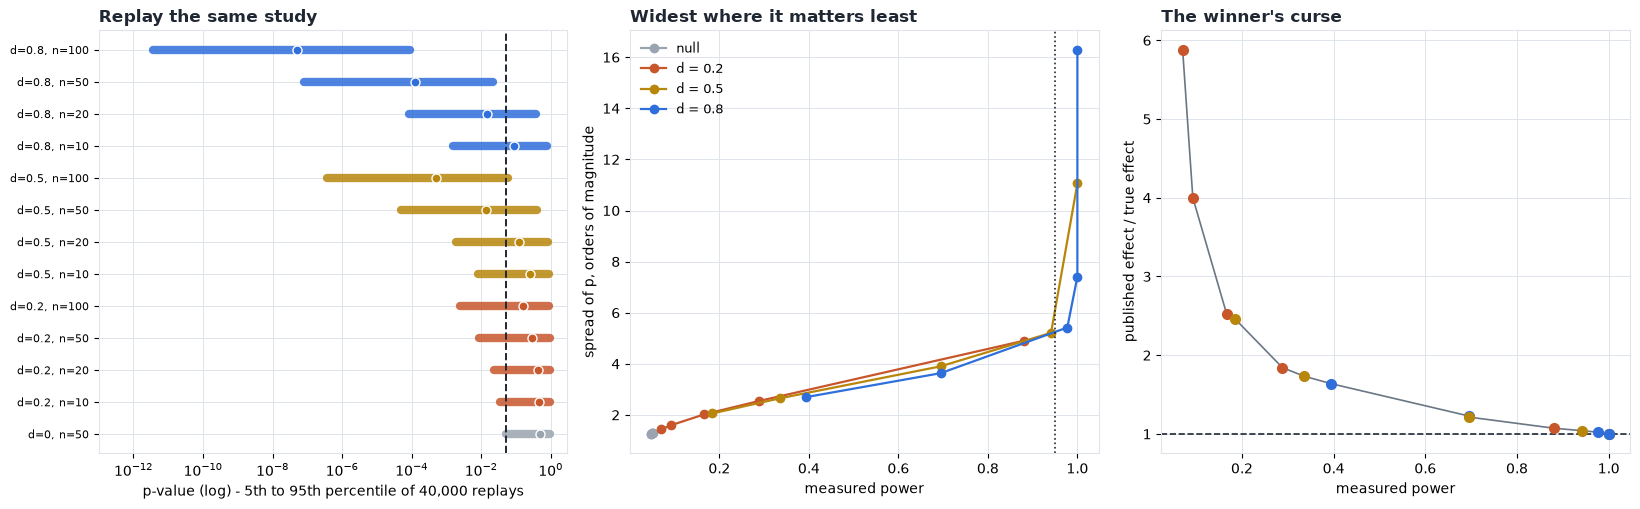

In [9]:
INK, MUTED, GRID, BG = "#1f2733", "#6b7684", "#dfe4ea", "#ffffff"
C = {0.0: "#9aa4b0", 0.2: "#c8562b", 0.5: "#b8860b", 0.8: "#2f6fdb"}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), facecolor=BG)
for ax in axes:
    ax.set_facecolor(BG); ax.grid(True, color=GRID, lw=0.7); ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(GRID)

# Range bars, not histograms: the question is whether the central 90% straddles 0.05, which a
# range against a reference line answers and a histogram does not.
ax = axes[0]
rows = [k for k in DESIGNS if k[1] <= 100 and (k[0] > 0 or k[1] == 50)]
for i, (d, n) in enumerate(rows):
    _, q, _ = spread[(d, n)]
    ax.plot([q[5], q[95]], [i, i], color=C[d], lw=6, solid_capstyle="round", alpha=0.85)
    ax.plot([q[50]], [i], "o", color=BG, ms=6.5, zorder=3)
    ax.plot([q[50]], [i], "o", color=C[d], ms=4.5, zorder=4)
ax.axvline(ALPHA, color=INK, ls="--", lw=1.4)
ax.set_xscale("log"); ax.set_xlim(1e-13, 3)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"d={d:g}, n={n}" for d, n in rows], fontsize=8)
ax.set_xlabel("p-value (log) - 5th to 95th percentile of 40,000 replays")
ax.set_title("Replay the same study", color=INK, fontsize=12, weight="bold", loc="left")

ax = axes[1]
for d in DS:
    pts = sorted([(spread[k][2], spread[k][0]) for k in DESIGNS if k[0] == d])
    ax.plot([p for p, _ in pts], [s for _, s in pts], "o-", color=C[d], lw=1.6, ms=6,
            label=f"d = {d:g}" if d else "null")
ax.axvline(0.95, color=INK, ls=":", lw=1.2)
ax.set_xlabel("measured power"); ax.set_ylabel("spread of p, orders of magnitude")
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("Widest where it matters least", color=INK, fontsize=12, weight="bold", loc="left")

ax = axes[2]
pts = sorted(curse.items(), key=lambda kv: kv[1][0])
ax.plot([v[0] for _, v in pts], [v[1] for _, v in pts], "-", color=MUTED, lw=1.2, zorder=1)
for k, v in pts:
    ax.plot([v[0]], [v[1]], "o", color=C[k[0]], ms=7, zorder=3)
ax.axhline(1.0, color=INK, ls="--", lw=1.2)
ax.set_xlabel("measured power"); ax.set_ylabel("published effect / true effect")
ax.set_title("The winner's curse", color=INK, fontsize=12, weight="bold", loc="left")

fig.tight_layout()
fig.savefig("notebook_figure.png", dpi=140, facecolor=BG)
plt.show()

## What to take away

1. The p-value really is a random variable and its spread really is enormous - but the spread is
   **largest at high power**, where it changes no decision. Raw spread is not the finding.
2. The decision-relevant version of the dance is **exactly** "power < 0.95". It carries no
   information beyond the power calculation you should already have run.
3. What power does *not* tell you is the **winner's curse**: at the lowest power measured here the
   significant results are inflated about 5.9x and roughly 13% of them point the wrong way.
4. **Conditioning on the observed p = 0.05 buys nothing.** The rerun's chance of significance is
   the plain unconditional power, on every design tested.
5. With a realistic prior, up to **83%** of significant findings here were null all along - and
   alpha never sees it.

The practical version: a p-value is not a bad instrument. It is a *narrow* one. It answers "how
surprising is this data if nothing is going on", and people routinely read it as an answer to
"how big is the effect", "will this replicate", and "how likely is my hypothesis" - three
questions it does not contain and that sections 3, 4 and 5 have to be run separately to answer.

## Try your own

Every table above is the same handful of moving parts: a true effect, a sample size, and how many
times you are willing to replay it. Change them.

In [10]:
# --- Your design -----------------------------------------------------------
# MY_D    = 0.35      # the true effect, in population SDs
# MY_N    = 30        # per group
# MY_REPS = 40000
#
# p, d_hat = simulate(MY_D, MY_N, MY_REPS, seed=0)
# sig = p < ALPHA
# q = {k: float(np.percentile(p, k)) for k in (5, 50, 95)}
#
# print(f"power           {sig.mean():.4f}   (analytic {analytic_power(MY_D, MY_N):.4f})")
# print(f"p, 5th pct      {q[5]:.2e}")
# print(f"p, median       {q[50]:.4f}")
# print(f"p, 95th pct     {q[95]:.4f}")
# print(f"straddles 0.05  {q[5] < ALPHA < q[95]}")
# print(f"type M          {np.mean(np.abs(d_hat[sig])) / MY_D:.2f}x")
# print(f"type S          {(d_hat[sig] < 0).mean():.4f}")
# print(f"n for 80% power {required_n(MY_D)} per group")

# --- Or: what would it take to make this study trustworthy? ----------------
# for n in (10, 20, 50, 100, 200, 400):
#     print(f"n={n:>4}  power={analytic_power(0.35, n):.3f}")

---

**Built by Phoebe Fu** - one mini product a day. [Repo](https://github.com/phoebefu6/phoebe-the-builder) ·
[This build](data-science-cookbook/p-value-dance)

The same study runs as a Streamlit app where you drag the design around instead of editing
constants:

```bash
pip install -r requirements.txt
streamlit run app.py
```

`evidence.py` regenerates every number quoted here into `evidence.txt` and `results.json`, and
`pytest` asserts the findings - including that each predicate is *capable* of returning either
answer, so none of them is a constant wearing a test.

Sibling builds in this domain: [`t-test-variants`](../t-test-variants) (which test),
[`normality-test-trap`](../normality-test-trap) and
[`assumption-pretest-cost`](../assumption-pretest-cost) (what the pretests cost). All three live
under a true null and measure how often a procedure rejects when it should not. This one is the
other side of that coin.